## 1. Importar bibliotecas e carregar o dataset

Bibliotecas importadas com sucesso!

📊 Dataset de casas carregado:
    tamanho_m2  preco_mil
0           50        150
1           60        180
2           70        210
3           80        240
4           90        270
5          100        300
6          110        330
7          120        360
8          130        390
9          140        420
10         150        450
11         160        480
12         170        510
13         180        540
14         190        570
15         200        600


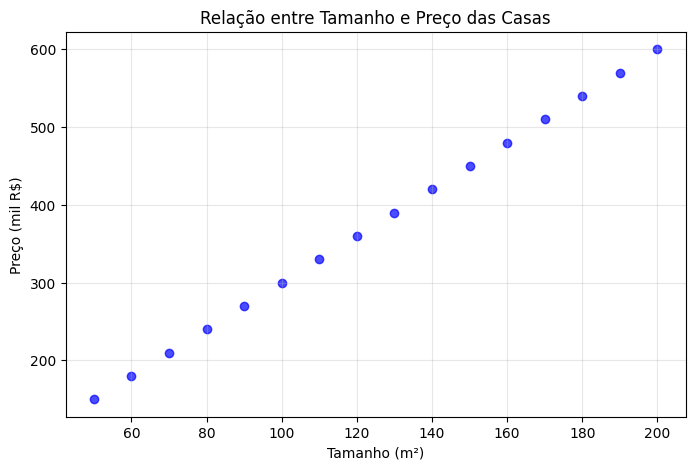


📈 Gráfico gerado! Parece que quanto maior o tamanho, maior o preço.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Bibliotecas importadas com sucesso!")

dados = {
    'tamanho_m2': [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200],
    'preco_mil': [150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600]
}

df = pd.DataFrame(dados)

print("\n📊 Dataset de casas carregado:")
print(df)

plt.figure(figsize=(8, 5))
plt.scatter(df['tamanho_m2'], df['preco_mil'], color='blue', alpha=0.7)
plt.xlabel('Tamanho (m²)')
plt.ylabel('Preço (mil R$)')
plt.title('Relação entre Tamanho e Preço das Casas')
plt.grid(True, alpha=0.3)
plt.show()

print("\n📈 Gráfico gerado! Parece que quanto maior o tamanho, maior o preço.")


## 2. Separar treino/teste, treinar o modelo e avaliar (proporção original: 80% treino / 20% teste)


In [2]:
X = df[['tamanho_m2']]
y = df['preco_mil']

print(f"🔹 X (tamanho das casas): {X.shape[0]} registros")
print(f"🔹 y (preço das casas): {y.shape[0]} registros")

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📚 Dados de treino: {len(X_treino)} casas")
print(f"🧪 Dados de teste: {len(X_teste)} casas")

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print("\n✅ Modelo treinado com sucesso!")

previsoes = modelo.predict(X_teste)

print("\n📋 Comparação entre valores reais e previstos:")
comparacao = pd.DataFrame({
    'Tamanho (m²)': X_teste.values.flatten(),
    'Preço Real (mil R$)': y_teste.values,
    'Preço Previsto (mil R$)': previsoes
})
print(comparacao)

r2 = r2_score(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_teste, previsoes)

print("\n📊 Métricas de Avaliação:")
print(f"   - R² (coeficiente de determinação): {r2:.4f}")
print(f"   - MSE (erro quadrático médio): {mse:.2f}")
print(f"   - RMSE (raiz do erro quadrático médio): {rmse:.2f}")
print(f"   - MAE (erro absoluto médio): {mae:.2f}")

if r2 > 0.9:
    print("\n✅ Interpretação: Modelo excelente! Explica mais de 90% da variação dos preços.")
elif r2 > 0.7:
    print("\n✅ Interpretação: Modelo bom! Explica mais de 70% da variação dos preços.")
else:
    print("\n⚠️ Interpretação: Modelo pode melhorar. Talvez mais dados ou outras variáveis ajudem.")

coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"\n📐 Equação da reta encontrada: Preço = {coeficiente:.2f} × Tamanho + {intercepto:.2f}")
print(f"   Significado: Cada 1m² a mais aumenta o preço em R$ {coeficiente:.2f} mil")


🔹 X (tamanho das casas): 16 registros
🔹 y (preço das casas): 16 registros

📚 Dados de treino: 12 casas
🧪 Dados de teste: 4 casas

✅ Modelo treinado com sucesso!

📋 Comparação entre valores reais e previstos:
   Tamanho (m²)  Preço Real (mil R$)  Preço Previsto (mil R$)
0            50                  150                    150.0
1            60                  180                    180.0
2           100                  300                    300.0
3           190                  570                    570.0

📊 Métricas de Avaliação:
   - R² (coeficiente de determinação): 1.0000
   - MSE (erro quadrático médio): 0.00
   - RMSE (raiz do erro quadrático médio): 0.00
   - MAE (erro absoluto médio): 0.00

✅ Interpretação: Modelo excelente! Explica mais de 90% da variação dos preços.

📐 Equação da reta encontrada: Preço = 3.00 × Tamanho + 0.00
   Significado: Cada 1m² a mais aumenta o preço em R$ 3.00 mil


## 3. Testando mudanças na proporção de treino/teste

- **70% treino / 30% teste**
- **90% treino / 10% teste**

In [3]:
proporcoes = [0.3, 0.1]  # 30% teste (70/30) e 10% teste (90/10)
nomes = ['70% treino / 30% teste', '90% treino / 10% teste']

resultados = []

for nome, prop in zip(nomes, proporcoes):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=prop, random_state=42)
    mod = LinearRegression()
    mod.fit(X_tr, y_tr)
    pred = mod.predict(X_te)
    r2_p = r2_score(y_te, pred)
    mse_p = mean_squared_error(y_te, pred)

    resultados.append({
        'Proporção': nome,
        'Casas treino': len(X_tr),
        'Casas teste': len(X_te),
        'R²': round(r2_p, 4),
        'MSE': round(mse_p, 4)
    })

    print(f"📌 {nome}")
    print(f"   Treino: {len(X_tr)} casas | Teste: {len(X_te)} casas")
    print(f"   R²: {r2_p:.4f}  |  MSE: {mse_p:.4f}")
    print("-" * 50)

df_resultados = pd.DataFrame(resultados)
print("\n📊 Resumo comparativo (incluindo o 80/20 original = R² 1.0000):")
print(df_resultados)


📌 70% treino / 30% teste
   Treino: 11 casas | Teste: 5 casas
   R²: 1.0000  |  MSE: 0.0000
--------------------------------------------------
📌 90% treino / 10% teste
   Treino: 14 casas | Teste: 2 casas
   R²: 1.0000  |  MSE: 0.0000
--------------------------------------------------

📊 Resumo comparativo (incluindo o 80/20 original = R² 1.0000):
                Proporção  Casas treino  Casas teste   R²  MSE
0  70% treino / 30% teste            11            5  1.0  0.0
1  90% treino / 10% teste            14            2  1.0  0.0


### 🔹 Qual foi o valor do R² obtido?

Na execução original (80% treino / 20% teste), o modelo obteve **R² = 1.0000** (R² perfeito).

Isso se repetiu também nas proporções testadas (70/30 e 90/10): em todas elas o R² permaneceu **1.0000**.

### 🔹 O que esse valor significa?

O R² (coeficiente de determinação) indica **quanto da variação dos dados o modelo consegue explicar**, variando de 0 a 1 (ou podendo ser negativo, em casos de modelos muito ruins):

- **R² = 1.0** → o modelo explica **100%** da variação do preço a partir do tamanho da casa. Ou seja, os pontos previstos caem exatamente sobre a reta de regressão, sem nenhum erro.
- **R² próximo de 0** → o modelo não explica quase nada da variação dos dados (a variável usada não ajuda a prever o resultado).

### 🔹 O que aconteceu quando você mudou a proporção de treino/teste?

Como o relacionamento entre tamanho e preço é perfeitamente linear (sem ruído nos dados), **o R² permaneceu em 1.0000 em todas as proporções testadas** (70/30, 80/20 e 90/10) — só mudou a quantidade de casas usadas para treinar e para testar o modelo:

| Proporção | Casas treino | Casas teste | R² |
|---|---|---|---|
| 70% treino / 30% teste | 11 | 5 | 1.0000 |
| 80% treino / 20% teste (original) | 12 | 4 | 1.0000 |
| 90% treino / 10% teste | 14 | 2 | 1.0000 |